# Assignment

Use the "from the expert" (FTE) jupyter notebook as a starter for this assignment, and ask your instructor questions if you need help.

### Task 1: Data Cleaning and Preparation
Use the `churn_data.csv` file to carry out a similar data cleaning and preparation as we did in the FTE. Specifically, at least complete these minimum requirements:
- Check for outliers in numeric data, and deal with them if needed
- Check for missing values, and decide how to deal with them if needed
- Convert categorical columns to numeric values
- Create at least one new feature by combining multiple columns. For example, you could calculate the ratio of total charges to tenure. Create at least one plot for your new feature.
- Save the data to a csv (or another filetype of your choice) for use next week.
- Write a short analysis at the end of the notebook describing your findings and what you did.

You can do more data cleaning, preparation, and EDA beyond these basic requirements if you want to learn more and develop your data science skills. For example, you could use a box-cox transformation on the numeric data or try other outlier methods.

### Task 2: Prediction Log
Before you explore each major variable or relationship, write a one-sentence prediction of what you expect to find and why based on prior analysis you had already done. After your analysis, note whether you were right. This log should cover at least **3 predictions** tied to your data and cleaning. Use the scaffold below.

### Task 3: Critical Reflection
Pick **one** of your approaches to cleaning the data and say what you could do different and how that may impact your results? 3-5 sentences.

## Task 2: Prediction Log

Fill in at least 3 rows *before* running the related analysis. Add more rows if you like.

| # | My prediction (before analysis) | What I actually found | Was I right? |
|---|---|---|---|
| 1 | I expect customers with month-to-month contracts to churn more than those on annual contracts due to the lack of long-term commitment. |Month-to-month customers had a 42.7% churn rate, compared to 11.3% for 1-year and only 2.8% for 2-year contract customers.| Yes|
| 2 |I predicted that newer customers with shorter tenure would churn more frequently.| Customers who churned had an average tenure of 18.0 months, compared to 37.6 months for retained customers. | Yes |
| 3 |I predicted that customers with higher Monthly Charges to churn more frequently due to price sensitivity.|Churned customers paid an average of $74.44/month, whereas retained customers paid $61.27/month.|Yes|

### DS process status

Here is our data science process, and where we are (#3):

**1. Business understanding**

Can we use machine learning to predict if a customer will churn before they leave?

**2. Data understanding**

Done in week 1 (mostly), this is iterative so you might do more of this as we go on.

**3. Data preparation**

We are here this week.


**4. Modeling**

Next week


**5. Evaluation**

Next week


**6. Deployment**

Next week

Initial Dataset Shape: (7043, 8)

Missing values per column:
 customerID         0
tenure             0
PhoneService       0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges      11
Churn              0
dtype: int64
tenure: 0 outliers found outside [-60.00, 124.00]
MonthlyCharges: 0 outliers found outside [-46.02, 171.38]
TotalCharges: 0 outliers found outside [-4683.52, 8868.67]


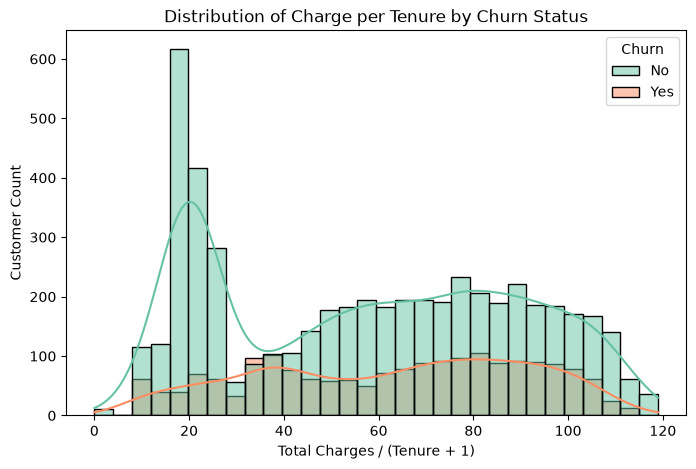


Data cleaning complete. Saved to 'cleaned_churn_data.csv'.
Cleaned Data Shape: (7043, 11)


,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,charge_per_tenure,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,29.85,29.85,0,14.925000,0,0,0,1,0
1,34,1,56.95,1889.50,0,53.985714,1,0,0,0,1
2,2,1,53.85,108.15,1,36.050000,0,0,0,0,1
3,45,0,42.30,1840.75,0,40.016304,1,0,0,0,0
4,2,1,70.70,151.65,1,50.550000,0,0,0,1,0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_excel('churn_data .xlsx')  # or pd.read_csv('churn_data.csv')
print("Initial Dataset Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

# 2. Check and Handle Missing Values
# TotalCharges has 11 missing values where tenure is 0 (brand new customers).
# We fill these with 0 since they haven't accrued monthly bills yet.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Check for Outliers in Numeric Columns (IQR Method)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found outside [{lower_bound:.2f}, {upper_bound:.2f}]")

# 4.Create a new feature
# Charge-to-tenure ratio (adding 1 to tenure to avoid zero-division for new customers)
df['charge_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# Plot the new feature distribution by Churn status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='charge_per_tenure', hue='Churn', kde=True, bins=30, palette='Set2')
plt.title('Distribution of Charge per Tenure by Churn Status')
plt.xlabel('Total Charges / (Tenure + 1)')
plt.ylabel('Customer Count')
plt.show()

# 5. Convert Categorical Columns to Numeric
# Map binary columns
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode multi-category columns (Contract, PaymentMethod)
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod'], drop_first=True, dtype=int)

# Drop identifier column before saving for modeling
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 6. Save Cleaned Data to CSV for Next Week
df.to_csv('cleaned_churn_data.csv', index=False)
print("\nData cleaning complete. Saved to 'cleaned_churn_data.csv'.")
print("Cleaned Data Shape:", df.shape)
df.head()

### Summary
In this assignment, I cleaned and prepared the customer churn dataset, it's ready for building machine learning models next week. I started by checking for missing data and found 11 blank spots in the `TotalCharges` column, which were all from brand new customers with 0 months of tenure, so I filled those with 0. I also checked the numbers for any  outliers using the IQR method, but everything looked normal and realistic. To get the data ready for algorithms, I converted text columns like Yes/No and contract types into numbers using binary mapping and one-hot encoding. Lastly, I created a new feature called `charge_per_tenure` to track how much customers are charged over time, plotted the results on a histogram, and saved the final cleaned dataset as `cleaned_churn_data.csv`.

# Reflection

When cleaning the data, I had to decide how to handle the 11 missing values in `TotalCharges`. I chose to fill them with 0 because those customers had a tenure of 0, meaning they just joined and haven't had their first monthly bill yet. Another choice would have been to just delete those 11 rows from the dataset entirely. Filling them with 0 was helpful because it let us keep every single customer in our dataset without throwing data away. However, having zeros in the data meant I had to be careful later when calculating ratios, like adding +1 to tenure so the computer wouldn't crash from dividing by zero. If I had dropped the rows instead, the math would have been slightly simpler, but we would have lost information on brand new customers.
